# Exercise 4 - Jonas Gstoettenmayr

## Transcript

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import shutil
import sys
from pathlib import Path
from video_pipeline.audio_extractor import probe_duration

In [3]:
SRC = Path.cwd() / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PREPARED = Path("prepared")
PREPARED.mkdir(exist_ok=True)

if shutil.which("ffmpeg") is None:
    raise SystemExit(
        "ffmpeg not found on PATH. Install it first (see the cell above):\n"
        "    sudo apt update && sudo apt install -y ffmpeg"
    )
print("ffmpeg:", shutil.which("ffmpeg"))

ffmpeg: /anaconda/envs/azureml_py38/bin/ffmpeg


In [4]:
STEM = "coldwar" 
mp4_path = PREPARED / f"{STEM}.mp4"
duration = probe_duration(mp4_path)

In [5]:
from video_pipeline.whisper_pipeline import WhisperPipeline

transcript_path = PREPARED / "transcript_small.json"
with WhisperPipeline() as wp:
    transcript = wp.transcribe(mp4_path, language="german")

transcript_path.write_text(transcript.model_dump_json(indent=2), encoding="utf-8")
print(f"{len(transcript.segments)} segments, {len(transcript.text)} chars -> {transcript_path}")

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[trans

4 segments, 1572 chars -> prepared/transcript_small.json


In [6]:
# Peek at the first few timestamped segments.
for seg in transcript.segments[:6]:
    print(f"[{seg.start:6.1f} - {seg.end:6.1f}s]  {seg.text}")

[   0.0 -   88.0s]  Nach dem Ende des Zweiten Weltkriegs 1945 beginnt eine neue Form von Krieg, ein Kalterkrieg. Zwischen den beiden Großmächten USA und der Sowjetunion. Kalt bedeutet das nicht geschossen, sondern nur, gedroht und aufgerüstet wird. Aber der Konflikt kann jederzeit eskalieren und das macht vielen Menschen Jahrzehnte lang Angst. Dabei haben sich die beiden Großmächte doch im Zweiten Weltkrieg erfolgreich mit Großbritannien und später mit dem befreiten Frankreich verbündet. Und so den gemeinsamen Feind, Nazi-Doltschland besiegt. Aber nachdem die Siegermächte Deutschland in vier Besatzungszonen aufgeteilt haben, ist die gute Zusammenarbeit beendet. Es beginnt ein aggressiver Wettstreit der Systeme, der 45 Jahre andauert. Die Sowjetunion und ihre sogenannten Bruder-Staaten im Osten gegen die USA und deren Verbündete im Westen. Die Grenze der beiden Blöcke verläuft mitten durch Deutschland. Denn aus der sowjetischen Besatzungszone wird 1949 ein eigener Bruder-Staat, die DDR.

## Translation

In [16]:
import json
from video_pipeline.qwen_text import QwenChat

In [17]:
transcript = json.loads((PREPARED / "transcript_small.json").read_text(encoding="utf-8"))
print(f"loaded transcript: {len(transcript['segments'])} segments, "
      f"{len(transcript['text'])} chars")
print("\nfirst 300 chars (German):\n", transcript["text"][:300])

loaded transcript: 4 segments, 1572 chars

first 300 chars (German):
 Nach dem Ende des Zweiten Weltkriegs 1945 beginnt eine neue Form von Krieg, ein Kalterkrieg. Zwischen den beiden Großmächten USA und der Sowjetunion. Kalt bedeutet das nicht geschossen, sondern nur, gedroht und aufgerüstet wird. Aber der Konflikt kann jederzeit eskalieren und das macht vielen Mensch


In [18]:
translated_segments = []
with QwenChat() as qc:
    for i, seg in enumerate(transcript["segments"], start=1):
        english = qc.translate(seg["text"], source="German", target="English")
        translated_segments.append({**seg, "text": english})
        print(f"[{i}/{len(transcript['segments'])}] {english[:70]}")

english_text = "\n".join(s["text"] for s in translated_segments)

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

/home/azureuser/localfiles/jonas_g/GAI4/HW_5/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[1/4] After the end of World War II in 1945, a new form of war emerges, a lo


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[2/4] The Cold War ended in 1991.


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[3/4] The translation of the German phrase "Es folgt eine Zeit der Ostwesten
[4/4] The translation of the given German text into English is: "But it is 2


In [19]:
from video_pipeline.models import TranslationResult

result = TranslationResult(
    source_path=str(PREPARED / "transcript_small.json"),
    source_language="German",
    target_language="English",
    source_text=transcript["text"],
    text=english_text,
)
out = PREPARED / "translation_small.json"
out.write_text(result.model_dump_json(indent=2), encoding="utf-8")
print("wrote", out, "-", len(english_text), "chars")

wrote prepared/translation_small.json - 7122 chars


In [20]:
# German vs English, side by side per segment.
for de, en in zip(transcript["segments"][:6], translated_segments[:6]):
    print(f"[{de['start']:6.1f}s] DE: {de['text']}")
    print(f"          EN: {en['text']}\n")

[   0.0s] DE: Nach dem Ende des Zweiten Weltkriegs 1945 beginnt eine neue Form von Krieg, ein Kalterkrieg. Zwischen den beiden Großmächten USA und der Sowjetunion. Kalt bedeutet das nicht geschossen, sondern nur, gedroht und aufgerüstet wird. Aber der Konflikt kann jederzeit eskalieren und das macht vielen Menschen Jahrzehnte lang Angst. Dabei haben sich die beiden Großmächte doch im Zweiten Weltkrieg erfolgreich mit Großbritannien und später mit dem befreiten Frankreich verbündet. Und so den gemeinsamen Feind, Nazi-Doltschland besiegt. Aber nachdem die Siegermächte Deutschland in vier Besatzungszonen aufgeteilt haben, ist die gute Zusammenarbeit beendet. Es beginnt ein aggressiver Wettstreit der Systeme, der 45 Jahre andauert. Die Sowjetunion und ihre sogenannten Bruder-Staaten im Osten gegen die USA und deren Verbündete im Westen. Die Grenze der beiden Blöcke verläuft mitten durch Deutschland. Denn aus der sowjetischen Besatzungszone wird 1949 ein eigener Bruder-Staat, die DDR. Es ge

## Summary

In [21]:
translation = json.loads((PREPARED / "translation_small.json").read_text(encoding="utf-8"))
english_text = translation["text"]
mp4_path = next(PREPARED.glob("*.mp4")) 
print("English transcript:", len(english_text), "chars")
print("video:", mp4_path, "exists:", mp4_path.exists())

English transcript: 7122 chars
video: prepared/coldwar.mp4 exists: True


In [22]:
from video_pipeline.qwen_text import QwenChat
from video_pipeline.models import SummaryResult

with QwenChat() as qc:
    summary = qc.summarize(english_text, language="English")

summary_result = SummaryResult(
    source_path=str(PREPARED / "translation_small.json"),
    language="English", source_text=english_text, summary=summary,
)
(PREPARED / "summary_small.json").write_text(summary_result.model_dump_json(indent=2), encoding="utf-8")
print(summary)

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


The translation of the German text into English is: "But it is 2022 with the other France on the Ukraine." However, the German text might need further clarification to understand its full meaning.


In [30]:
from video_pipeline.qwen_text import QwenChat
from video_pipeline.models import SummaryResult

translation = json.loads((PREPARED / "translation.json").read_text(encoding="utf-8"))
english_text = translation["text"]

with QwenChat() as qc:
    summary = qc.summarize(english_text, language="English")

summary_result = SummaryResult(
    source_path=str(PREPARED / "translation.json"),
    language="English", source_text=english_text, summary=summary,
)
(PREPARED / "summary_small_proper.json").write_text(summary_result.model_dump_json(indent=2), encoding="utf-8")
print(summary)

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


After World War II in 1945, a new form of war begins, a Cold War between the United States and the Soviet Union. This conflict is characterized by threats and armaments, but not actual shots being fired. The Cold War is a period of intense competition and rivalry between the two superpowers, with both sides trying to outdo each other in terms of military and technological advancements, as well as in terms of political and ideological influence. The conflict can escalate at any time, which has led to widespread fear and concern for decades.

The two superpowers have had a history of collaboration, but this has been largely limited to the context of the war against Nazi Germany. After the war, the Soviet Union and its "brother states in the East" formed the Eastern Bloc, while the United States and its "companies" formed the Western Bloc. The Soviet Union and its "brother states" in the East eventually formed the GDR, while the United States and its "companies" in the West formed the US 

## OCR

In [23]:
import torch
import gc
gc.collect()


torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [27]:
from video_pipeline.ocr_pipeline import OCRPipeline

# TODONE (Exercise 3b): OCR the video at one frame per second.
with OCRPipeline() as op:
    ocr = op.run(mp4_path, fps=1)

ocr_path = PREPARED / "ocr_small.json"
ocr_path.write_text(ocr.model_dump_json(indent=2), encoding="utf-8")
print(f"{ocr.frame_count} frames, {len(ocr.unique_text_blocks)} unique text blocks")

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

/home/azureuser/localfiles/jonas_g/GAI4/HW_5/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
/home/azureuser/localfiles/jonas_g/GAI4/HW_5/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` 

100 frames, 7 unique text blocks


In [25]:
print("=== Unique on-screen text blocks ===")
for block in ocr.unique_text_blocks:
    print("-", block.replace("\n", " / "))

=== Unique on-screen text blocks ===
- Der Kaltes Krig
- Der Kalte Krieg in 100 Sekunden
- 1945
- WDR
- 1949
- no text
- WDR 2023


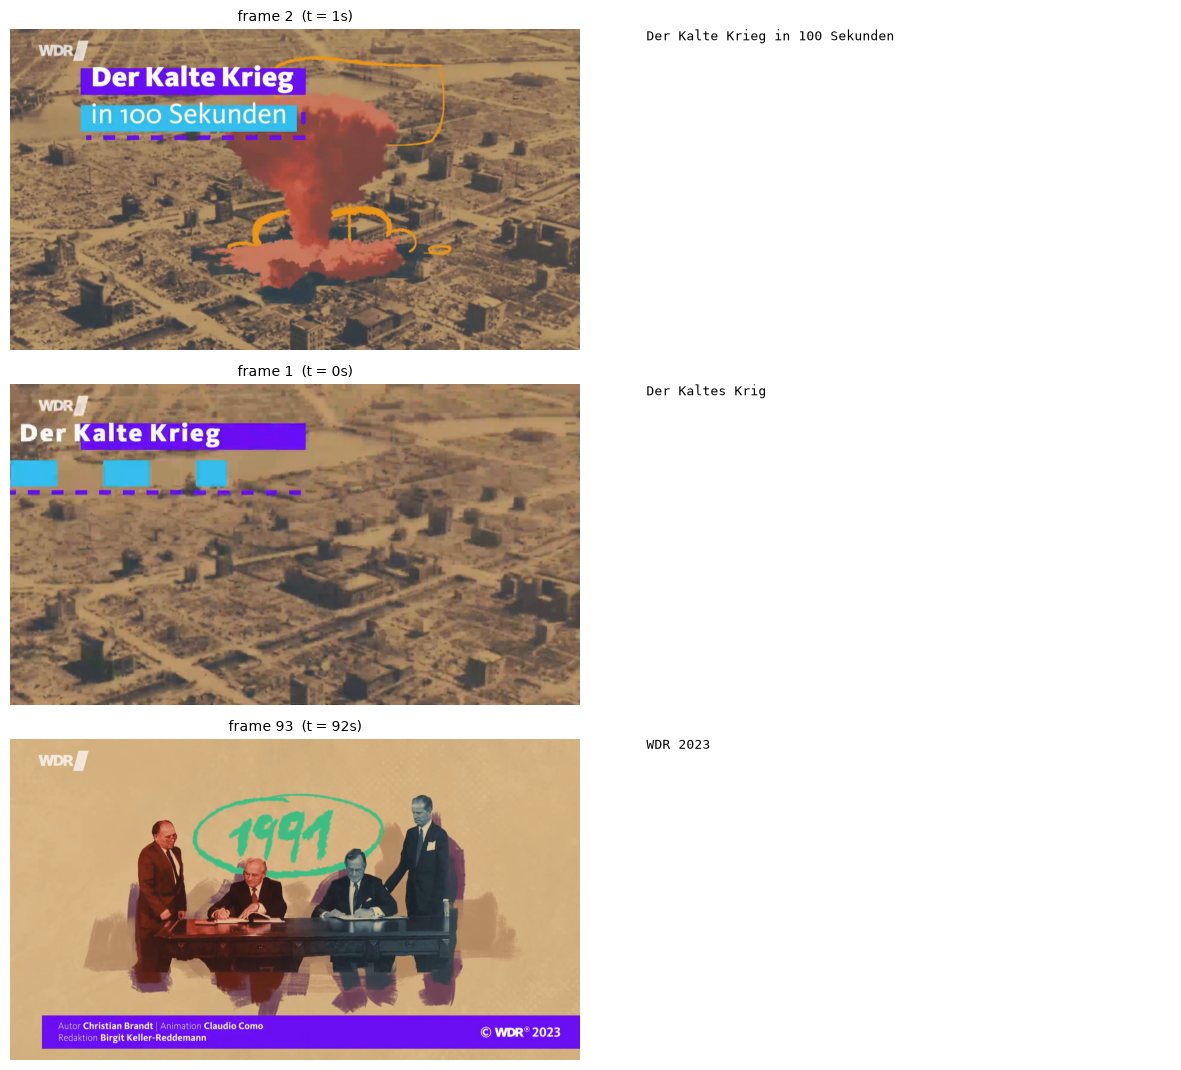

In [26]:
import tempfile, textwrap
import matplotlib.pyplot as plt
from PIL import Image
from video_pipeline.frame_extractor import extract_frames

# Re-sample frames at the same fps the OCR used so frame_number lines up.
tmp = Path(tempfile.mkdtemp(prefix="vp_show_"))
frames = extract_frames(mp4_path, fps=ocr.fps, output_dir=tmp)
by_number = {fr.frame_number: fr.path for fr in frames}

# Top 3 frames by amount of OCR text, skipping near-duplicate text so the
# panels show distinct on-screen content.
top, seen = [], set()
for f in sorted(ocr.frames, key=lambda fr: len(fr.text), reverse=True):
    key = " ".join(f.text.split()).lower()
    if not key or key in seen:
        continue
    seen.add(key)
    top.append(f)
    if len(top) == 3:
        break

fig, axes = plt.subplots(len(top), 2, figsize=(13, 3.6 * len(top)),
                         gridspec_kw={"width_ratios": [3, 2]})
axes = axes.reshape(len(top), 2)
for (ax_img, ax_txt), f in zip(axes, top):
    ax_img.imshow(Image.open(by_number[f.frame_number]).convert("RGB"))
    ax_img.set_title(f"frame {f.frame_number}  (t = {f.timestamp:.0f}s)", fontsize=10)
    ax_img.axis("off")
    ax_txt.axis("off")
    body = "\n".join(textwrap.fill(line, 46) for line in f.text.splitlines())
    ax_txt.text(0.0, 1.0, body, va="top", ha="left", family="monospace", fontsize=9)
plt.tight_layout()
plt.show()

shutil.rmtree(tmp, ignore_errors=True)